# Tarea 3 — Parte 1  
## Denoising de Imágenes Astronómicas con Starlets y MMT

Este notebook implementa la Parte 1 de la Tarea 3:

- Degradación con ruido gaussiano y uniforme.
- Denoising con Starlets usando dos filtros de suavizado.
- Denoising con MMT usando distintos kernels de vecindad.
- Umbralización hard y soft.
- Evaluación con RMSE, SSIM y HaarPSI.
- Tablas y visualizaciones comparativas.

> Imágenes usadas:
> - Imagen lunar: alta frecuencia de detalles y fuertes contrastes.
> - Imagen de cielo profundo: estructuras difusas y bajo contraste.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.ndimage import convolve, median_filter
from skimage import io, img_as_float
from skimage.color import rgb2gray, rgba2rgb
from skimage.metrics import structural_similarity as ssim
from skimage.morphology import diamond, disk

ROOT = Path.cwd()

# Si se ejecuta desde notebooks/task3, subimos dos niveles.
if ROOT.name == "task3":
    ROOT = ROOT.parents[1]
elif ROOT.name == "notebooks":
    ROOT = ROOT.parent

SRC = ROOT / "src"
if SRC.exists() and str(SRC) not in sys.path:
    sys.path.append(str(SRC))

DATA_DIR = ROOT / "data" / "raw" / "task2"
RESULTS_DIR = ROOT / "results" / "task3" / "part1"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("ROOT:", ROOT)
print("DATA_DIR:", DATA_DIR)
print("RESULTS_DIR:", RESULTS_DIR)

ROOT: /Users/pabpobar/Proyects/Courses/ProcMultiescImgs/repos/proc-multiesc-imgs
DATA_DIR: /Users/pabpobar/Proyects/Courses/ProcMultiescImgs/repos/proc-multiesc-imgs/data/raw/task2
RESULTS_DIR: /Users/pabpobar/Proyects/Courses/ProcMultiescImgs/repos/proc-multiesc-imgs/results/task3/part1


## 1. Utilidades generales

Estas funciones permiten cargar imágenes en escala de grises, normalizarlas al intervalo `[0, 1]` y calcular métricas.

In [2]:
def load_grayscale_image(path):
    """
    Carga una imagen RGB/RGBA/grayscale y la convierte a float en [0, 1].
    """
    img = io.imread(path)
    img = img_as_float(img)

    if img.ndim == 3:
        if img.shape[-1] == 4:
            img = rgba2rgb(img)
        img = rgb2gray(img)

    return np.clip(img, 0.0, 1.0)


def show_images(images, titles=None, ncols=3, figsize=(14, 5), cmap="gray"):
    n = len(images)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    axes = np.array(axes).reshape(-1)

    for i, ax in enumerate(axes):
        ax.axis("off")
        if i < n:
            ax.imshow(images[i], cmap=cmap, vmin=0, vmax=1)
            if titles is not None:
                ax.set_title(titles[i])

    plt.tight_layout()
    return fig


def rmse(x, y):
    return float(np.sqrt(np.mean((np.asarray(x) - np.asarray(y)) ** 2)))


def haarpsi_fallback(x, y):
    """
    Aproximación simple tipo HaarPSI basada en gradientes Haar.
    Si el repo tiene una implementación más completa en course_utils.wavepsi,
    puede reemplazarse esta función por dicha versión.
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    hx = x[:, 1:] - x[:, :-1]
    hy = y[:, 1:] - y[:, :-1]
    vx = x[1:, :] - x[:-1, :]
    vy = y[1:, :] - y[:-1, :]

    c = 1e-6

    sim_h = (2 * hx * hy + c) / (hx**2 + hy**2 + c)
    sim_v = (2 * vx * vy + c) / (vx**2 + vy**2 + c)

    score = 0.5 * (np.mean(sim_h) + np.mean(sim_v))
    return float(np.clip(score, -1.0, 1.0))


def compute_metrics(reference, estimate):
    reference = np.asarray(reference, dtype=float)
    estimate = np.clip(np.asarray(estimate, dtype=float), 0.0, 1.0)

    return {
        "RMSE": rmse(reference, estimate),
        "SSIM": float(ssim(reference, estimate, data_range=1.0)),
        "HaarPSI": haarpsi_fallback(reference, estimate),
    }

## 2. Carga de imágenes

Coloca las imágenes en:

```text
data/raw/task2/Moon.png
data/raw/task2/EX3_01.png
```

Si tienen otros nombres, cambia las rutas en la celda siguiente.

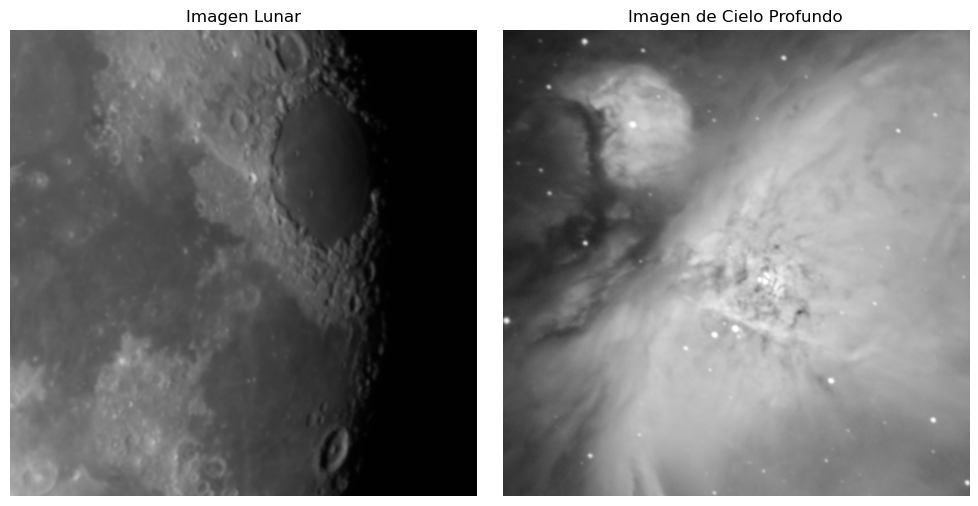

Moon: (550, 550) 0.005335294117647059 0.7899098039215686
Deep sky: (800, 800) 0.09019607843137255 1.0


In [3]:
moon_path = DATA_DIR / "Moon.png"
deep_path = DATA_DIR / "EX3_01.png"

# Alternativa si copiaste los archivos junto al notebook.
if not moon_path.exists():
    moon_path = Path("Moon.png")
if not deep_path.exists():
    deep_path = Path("EX3_01.png")

moon = load_grayscale_image(moon_path)
deep_sky = load_grayscale_image(deep_path)

images = {
    "moon": moon,
    "deep_sky": deep_sky,
}

fig = show_images(
    [moon, deep_sky],
    ["Imagen Lunar", "Imagen de Cielo Profundo"],
    ncols=2,
    figsize=(10, 5),
)
plt.show()

print("Moon:", moon.shape, moon.min(), moon.max())
print("Deep sky:", deep_sky.shape, deep_sky.min(), deep_sky.max())

## 3. Degradación con ruido

Se usan dos tipos de ruido:

1. **Ruido gaussiano aditivo**: `I_n = I + epsilon`, con `epsilon ~ N(0, sigma^2)`.
2. **Ruido uniforme aditivo**: `I_n = I + epsilon`, con `epsilon ~ U(-a, a)`.

Los parámetros pueden ajustarse para coincidir con los usados en la Tarea 2.

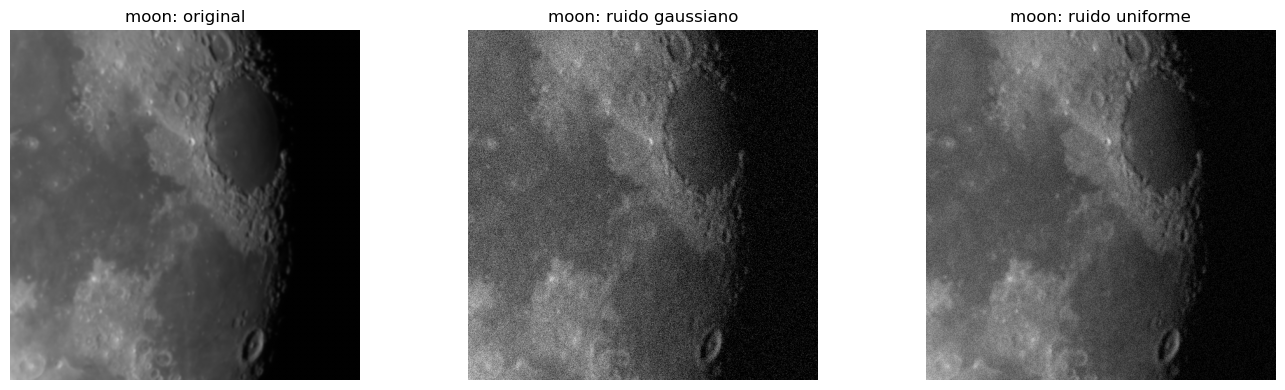

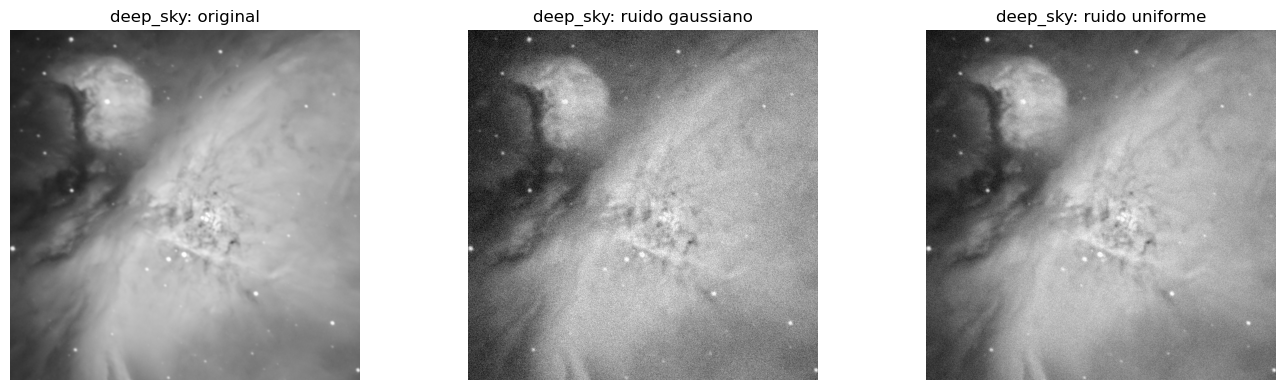

In [4]:
def add_gaussian_noise(image, sigma=0.08, seed=0):
    rng = np.random.default_rng(seed)
    noisy = image + rng.normal(0.0, sigma, size=image.shape)
    return np.clip(noisy, 0.0, 1.0)


def add_uniform_noise(image, low=-0.08, high=0.08, seed=0):
    rng = np.random.default_rng(seed)
    noisy = image + rng.uniform(low, high, size=image.shape)
    return np.clip(noisy, 0.0, 1.0)


NOISE_CONFIGS = {
    "gaussian": {"sigma": 0.08},
    "uniform": {"low": -0.08, "high": 0.08},
}

noisy_images = {}

for name, img in images.items():
    noisy_images[(name, "gaussian")] = add_gaussian_noise(
        img,
        sigma=NOISE_CONFIGS["gaussian"]["sigma"],
        seed=10,
    )
    noisy_images[(name, "uniform")] = add_uniform_noise(
        img,
        low=NOISE_CONFIGS["uniform"]["low"],
        high=NOISE_CONFIGS["uniform"]["high"],
        seed=20,
    )

for name, img in images.items():
    fig = show_images(
        [
            img,
            noisy_images[(name, "gaussian")],
            noisy_images[(name, "uniform")],
        ],
        [
            f"{name}: original",
            f"{name}: ruido gaussiano",
            f"{name}: ruido uniforme",
        ],
        ncols=3,
        figsize=(14, 4),
    )
    plt.show()

## 4. Starlet 2D

La transformada Starlet produce aproximaciones suaves `c_j` y detalles `w_j`:

```text
w_j = c_{j-1} - c_j
```

La reconstrucción se obtiene mediante:

```text
I = c_J + sum_j w_j
```

Se implementan dos filtros de suavizado:

- `b3spline`: filtro clásico B3-spline.
- `binomial3`: filtro binomial compacto.

In [5]:
def kernel_1d(kind="b3spline"):
    kind = kind.lower()

    if kind in {"b3", "b3spline", "b3-spline"}:
        return np.array([1, 4, 6, 4, 1], dtype=float) / 16.0

    if kind in {"binomial3", "binom3"}:
        return np.array([1, 2, 1], dtype=float) / 4.0

    raise ValueError("kind must be one of {'b3spline', 'binomial3'}")


def atrous_kernel_2d(kind="b3spline", level=0):
    h = kernel_1d(kind)
    k = np.outer(h, h)

    if level == 0:
        return k

    step = 2 ** level
    size = k.shape[0]
    new_size = size + (size - 1) * (step - 1)
    out = np.zeros((new_size, new_size), dtype=float)

    for i in range(size):
        for j in range(size):
            out[i * step, j * step] = k[i, j]

    return out


def starlet_transform_2d(image, n_scales=5, kernel="b3spline"):
    image = np.asarray(image, dtype=float)

    c = image.copy()
    details = []
    approximations = [c.copy()]

    for j in range(n_scales):
        h = atrous_kernel_2d(kernel, level=j)
        c_next = convolve(c, h, mode="mirror")
        w = c - c_next

        details.append(w)
        c = c_next
        approximations.append(c.copy())

    return details, c, approximations


def starlet_reconstruct_2d(details, cJ):
    rec = np.asarray(cJ, dtype=float).copy()
    for w in details:
        rec += w
    return rec

## 5. MMT 2D

La Transformada Multiescala de Mediana usa filtros de mediana con vecindades crecientes.

A diferencia de Starlet, el suavizado es no lineal, lo que puede ayudar a preservar ciertas estructuras locales.

In [6]:
def get_mmt_footprint(kernel_type="square", radius=1):
    if radius < 1:
        raise ValueError("radius must be >= 1")

    kernel_type = kernel_type.lower()

    if kernel_type == "square":
        size = 2 * radius + 1
        return np.ones((size, size), dtype=bool)

    if kernel_type == "diamond":
        return diamond(radius).astype(bool)

    if kernel_type in {"circle", "disk"}:
        return disk(radius).astype(bool)

    raise ValueError("kernel_type must be one of {'square', 'diamond', 'circle'}")


def mmt_transform_2d(image, n_scales=5, kernel_type="square", base_radius=1):
    image = np.asarray(image, dtype=float)

    c = image.copy()
    details = []
    approximations = [c.copy()]

    for j in range(n_scales):
        radius = base_radius * (2 ** j)
        footprint = get_mmt_footprint(kernel_type, radius)
        c_next = median_filter(c, footprint=footprint, mode="reflect")

        w = c - c_next
        details.append(w)
        c = c_next
        approximations.append(c.copy())

    return details, c, approximations


def mmt_reconstruct_2d(details, cJ):
    rec = np.asarray(cJ, dtype=float).copy()
    for w in details:
        rec += w
    return rec


def average_mmt_square_diamond(image, n_scales=5, base_radius=1):
    d_sq, c_sq, _ = mmt_transform_2d(
        image,
        n_scales=n_scales,
        kernel_type="square",
        base_radius=base_radius,
    )
    d_di, c_di, _ = mmt_transform_2d(
        image,
        n_scales=n_scales,
        kernel_type="diamond",
        base_radius=base_radius,
    )

    details = [0.5 * (a + b) for a, b in zip(d_sq, d_di)]
    cJ = 0.5 * (c_sq + c_di)

    return details, cJ

## 6. Umbralización

Se aplica umbralización sobre los coeficientes de detalle.

La estimación robusta del ruido se basa en MAD:

```text
sigma_hat = median(|w - median(w)|) / 0.6745
```

Para cada escala se usa:

```text
T_j = lambda * sigma_hat_j
```

In [7]:
def mad_sigma(x):
    x = np.asarray(x, dtype=float)
    med = np.median(x)
    return np.median(np.abs(x - med)) / 0.6745


def hard_threshold(x, t):
    return x * (np.abs(x) >= t)


def soft_threshold(x, t):
    return np.sign(x) * np.maximum(np.abs(x) - t, 0.0)


def threshold_details(details, threshold_kind="soft", lam=3.0):
    out = []

    for w in details:
        sigma = mad_sigma(w)
        t = lam * sigma

        if threshold_kind == "soft":
            out.append(soft_threshold(w, t))
        elif threshold_kind == "hard":
            out.append(hard_threshold(w, t))
        else:
            raise ValueError("threshold_kind must be 'soft' or 'hard'")

    return out

## 7. Pipeline de denoising

Se comparan:

- Starlet con `b3spline` y `binomial3`.
- MMT con kernels `square`, `diamond` y `circle`.
- Umbralización `soft` y `hard`.
- 5 niveles de descomposición.

In [8]:
N_SCALES = 5
LAMBDA = 3.0

starlet_kernels = ["b3spline", "binomial3"]
mmt_kernels = ["square", "diamond", "circle"]
thresholds = ["soft", "hard"]

results = []
reconstructions = {}

# Métricas de imágenes ruidosas
for image_name, clean in images.items():
    for noise_name in ["gaussian", "uniform"]:
        noisy = noisy_images[(image_name, noise_name)]
        metrics = compute_metrics(clean, noisy)

        results.append({
            "image": image_name,
            "noise": noise_name,
            "method": "noisy",
            "variant": "none",
            "threshold": "none",
            "n_scales": 0,
            **metrics,
        })

# Starlet
for image_name, clean in images.items():
    for noise_name in ["gaussian", "uniform"]:
        noisy = noisy_images[(image_name, noise_name)]

        for kernel in starlet_kernels:
            details, cJ, _ = starlet_transform_2d(
                noisy,
                n_scales=N_SCALES,
                kernel=kernel,
            )

            for thr in thresholds:
                details_thr = threshold_details(details, threshold_kind=thr, lam=LAMBDA)
                rec = starlet_reconstruct_2d(details_thr, cJ)
                rec = np.clip(rec, 0.0, 1.0)

                key = (image_name, noise_name, "starlet", kernel, thr)
                reconstructions[key] = rec

                metrics = compute_metrics(clean, rec)
                results.append({
                    "image": image_name,
                    "noise": noise_name,
                    "method": "starlet",
                    "variant": kernel,
                    "threshold": thr,
                    "n_scales": N_SCALES,
                    **metrics,
                })

# MMT
for image_name, clean in images.items():
    for noise_name in ["gaussian", "uniform"]:
        noisy = noisy_images[(image_name, noise_name)]

        for kernel in mmt_kernels:
            details, cJ, _ = mmt_transform_2d(
                noisy,
                n_scales=N_SCALES,
                kernel_type=kernel,
                base_radius=1,
            )

            for thr in thresholds:
                details_thr = threshold_details(details, threshold_kind=thr, lam=LAMBDA)
                rec = mmt_reconstruct_2d(details_thr, cJ)
                rec = np.clip(rec, 0.0, 1.0)

                key = (image_name, noise_name, "mmt", kernel, thr)
                reconstructions[key] = rec

                metrics = compute_metrics(clean, rec)
                results.append({
                    "image": image_name,
                    "noise": noise_name,
                    "method": "mmt",
                    "variant": kernel,
                    "threshold": thr,
                    "n_scales": N_SCALES,
                    **metrics,
                })

# Bono: promedio square + diamond
for image_name, clean in images.items():
    for noise_name in ["gaussian", "uniform"]:
        noisy = noisy_images[(image_name, noise_name)]

        details, cJ = average_mmt_square_diamond(
            noisy,
            n_scales=N_SCALES,
            base_radius=1,
        )

        for thr in thresholds:
            details_thr = threshold_details(details, threshold_kind=thr, lam=LAMBDA)
            rec = mmt_reconstruct_2d(details_thr, cJ)
            rec = np.clip(rec, 0.0, 1.0)

            key = (image_name, noise_name, "mmt_avg", "square+diamond", thr)
            reconstructions[key] = rec

            metrics = compute_metrics(clean, rec)
            results.append({
                "image": image_name,
                "noise": noise_name,
                "method": "mmt_avg",
                "variant": "square+diamond",
                "threshold": thr,
                "n_scales": N_SCALES,
                **metrics,
            })

df_results = pd.DataFrame(results)
df_results.head()

,image,noise,method,variant,threshold,n_scales,RMSE,SSIM,HaarPSI
0,moon,gaussian,noisy,none,none,0,0.074800,0.179562,0.063046
1,moon,uniform,noisy,none,none,0,0.043418,0.379777,0.075846
2,deep_sky,gaussian,noisy,none,none,0,0.079897,0.157798,0.010453
3,deep_sky,uniform,noisy,none,none,0,0.046172,0.346589,0.021901
4,moon,gaussian,starlet,b3spline,soft,5,0.030779,0.731390,0.459684


## 8. Tabla comparativa

Se ordena por menor RMSE y mayor SSIM.

In [9]:
df_sorted = df_results.sort_values(
    by=["image", "noise", "RMSE", "SSIM"],
    ascending=[True, True, True, False],
)

display(df_sorted)

csv_path = RESULTS_DIR / "part1_denoising_metrics.csv"
df_sorted.to_csv(csv_path, index=False)
print("Saved:", csv_path)

,image,noise,method,variant,threshold,n_scales,RMSE,SSIM,HaarPSI
48,deep_sky,gaussian,mmt_avg,square+diamond,soft,5,0.016711,0.921846,0.422336
32,deep_sky,gaussian,mmt,square,soft,5,0.017438,0.927124,0.412288
34,deep_sky,gaussian,mmt,diamond,soft,5,0.017500,0.873632,0.365902
36,deep_sky,gaussian,mmt,circle,soft,5,0.018598,0.871510,0.369079
15,deep_sky,gaussian,starlet,binomial3,hard,5,0.019909,0.885921,0.438453
14,deep_sky,gaussian,starlet,binomial3,soft,5,0.021077,0.940245,0.441811
13,deep_sky,gaussian,starlet,b3spline,hard,5,0.022753,0.881422,0.431087
12,deep_sky,gaussian,starlet,b3spline,soft,5,0.025179,0.934840,0.434115
33,deep_sky,gaussian,mmt,square,hard,5,0.031221,0.640090,0.389819
49,deep_sky,gaussian,mmt_avg,square+diamond,hard,5,0.034553,0.581473,0.402909


Saved: /Users/pabpobar/Proyects/Courses/ProcMultiescImgs/repos/proc-multiesc-imgs/results/task3/part1/part1_denoising_metrics.csv


In [10]:
best_results = (
    df_results[df_results["method"] != "noisy"]
    .sort_values(by=["image", "noise", "RMSE", "SSIM"], ascending=[True, True, True, False])
    .groupby(["image", "noise"])
    .head(5)
)

display(best_results)

,image,noise,method,variant,threshold,n_scales,RMSE,SSIM,HaarPSI
48,deep_sky,gaussian,mmt_avg,square+diamond,soft,5,0.016711,0.921846,0.422336
32,deep_sky,gaussian,mmt,square,soft,5,0.017438,0.927124,0.412288
34,deep_sky,gaussian,mmt,diamond,soft,5,0.017500,0.873632,0.365902
36,deep_sky,gaussian,mmt,circle,soft,5,0.018598,0.871510,0.369079
15,deep_sky,gaussian,starlet,binomial3,hard,5,0.019909,0.885921,0.438453
40,deep_sky,uniform,mmt,diamond,soft,5,0.013936,0.944718,0.408007
51,deep_sky,uniform,mmt_avg,square+diamond,hard,5,0.014160,0.905280,0.434421
50,deep_sky,uniform,mmt_avg,square+diamond,soft,5,0.014940,0.952781,0.453844
19,deep_sky,uniform,starlet,binomial3,hard,5,0.015086,0.952247,0.449492
39,deep_sky,uniform,mmt,square,hard,5,0.015287,0.886781,0.411289


## 9. Visualización de mejores reconstrucciones

Para cada imagen y tipo de ruido se muestran:

- original;
- imagen degradada;
- mejor reconstrucción según RMSE;
- mapa de error absoluto.

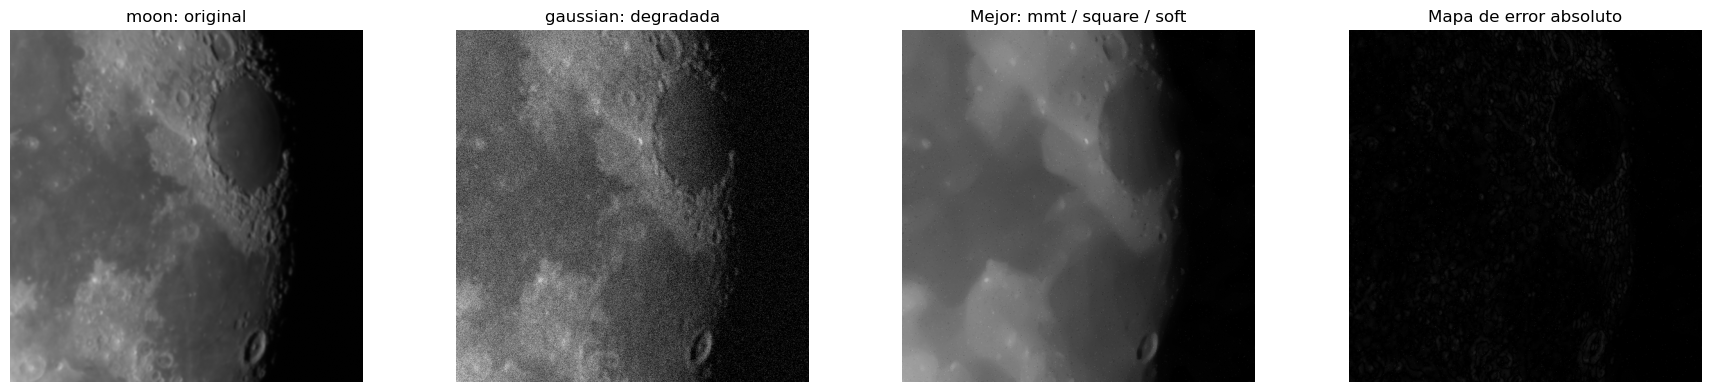

image            moon
noise        gaussian
method            mmt
variant        square
threshold        soft
RMSE         0.021304
SSIM         0.841946
HaarPSI      0.414762
Name: 20, dtype: object


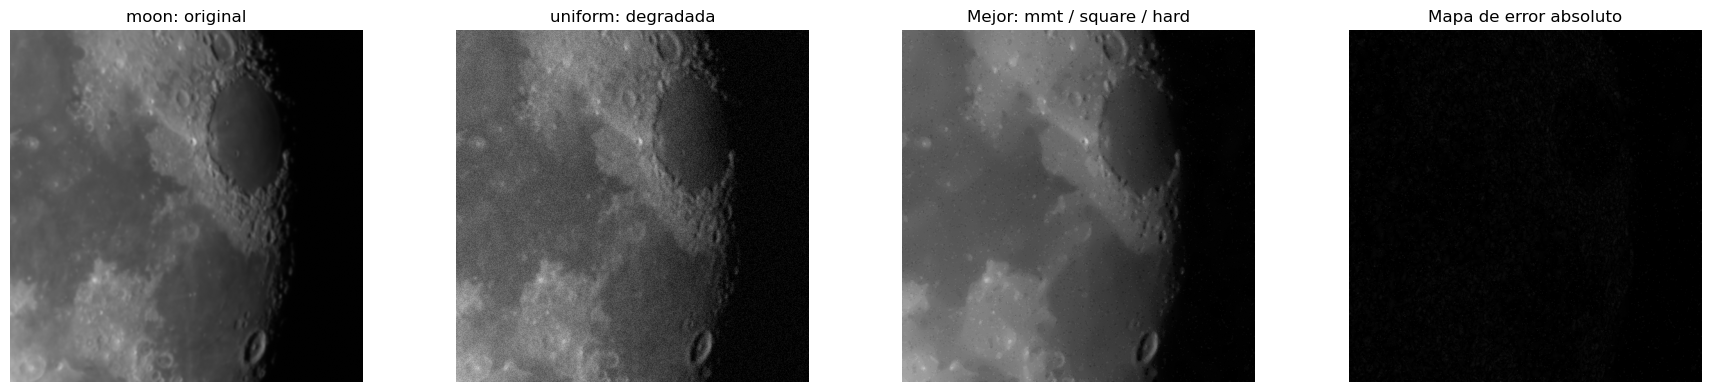

image            moon
noise         uniform
method            mmt
variant        square
threshold        hard
RMSE         0.017916
SSIM         0.835997
HaarPSI      0.436501
Name: 27, dtype: object


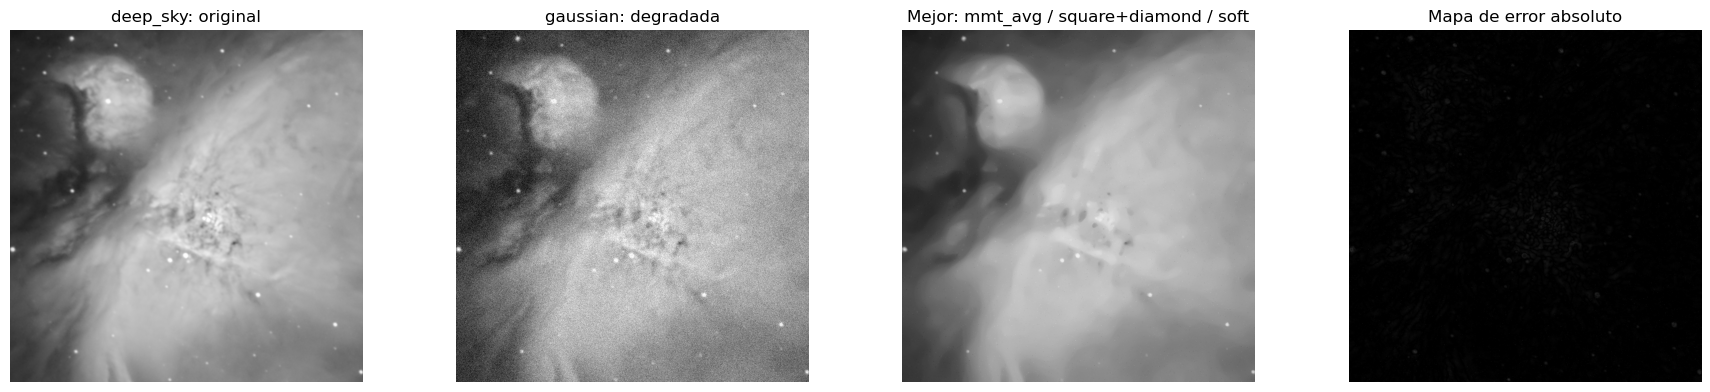

image              deep_sky
noise              gaussian
method              mmt_avg
variant      square+diamond
threshold              soft
RMSE               0.016711
SSIM               0.921846
HaarPSI            0.422336
Name: 48, dtype: object


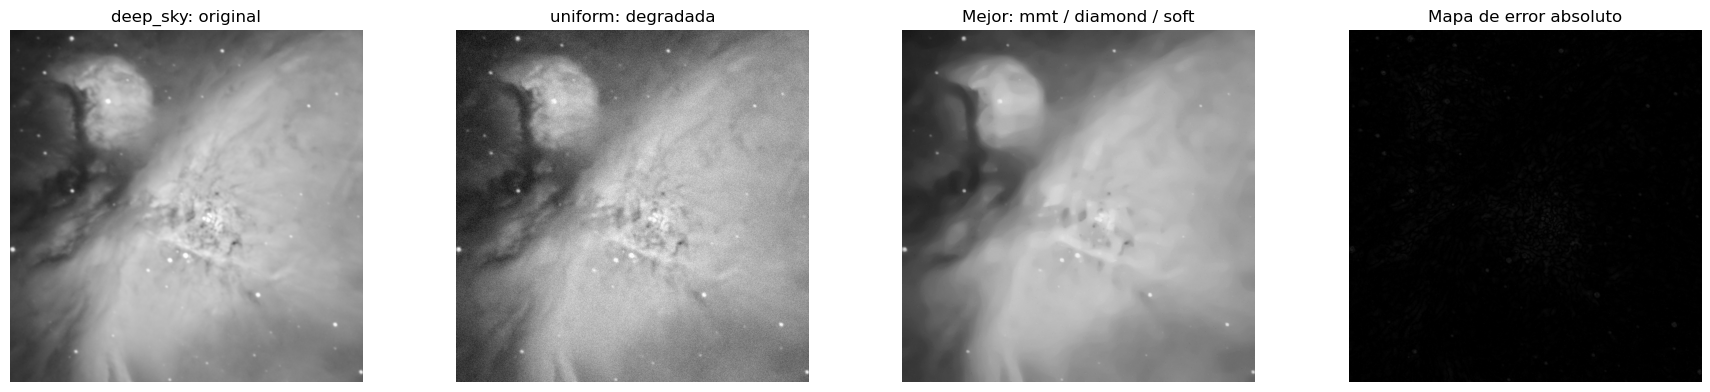

image        deep_sky
noise         uniform
method            mmt
variant       diamond
threshold        soft
RMSE         0.013936
SSIM         0.944718
HaarPSI      0.408007
Name: 40, dtype: object


In [11]:
for image_name, clean in images.items():
    for noise_name in ["gaussian", "uniform"]:
        subset = df_results[
            (df_results["image"] == image_name)
            & (df_results["noise"] == noise_name)
            & (df_results["method"] != "noisy")
        ].sort_values("RMSE")

        best = subset.iloc[0]
        key = (
            best["image"],
            best["noise"],
            best["method"],
            best["variant"],
            best["threshold"],
        )

        best_rec = reconstructions[key]

        fig = show_images(
            [
                clean,
                noisy_images[(image_name, noise_name)],
                best_rec,
                np.abs(clean - best_rec),
            ],
            [
                f"{image_name}: original",
                f"{noise_name}: degradada",
                f"Mejor: {best['method']} / {best['variant']} / {best['threshold']}",
                "Mapa de error absoluto",
            ],
            ncols=4,
            figsize=(18, 4),
        )
        plt.show()

        print(best[["image", "noise", "method", "variant", "threshold", "RMSE", "SSIM", "HaarPSI"]])

## 10. Visualización de descomposiciones

Se muestran los coeficientes de detalle para Starlet y MMT.

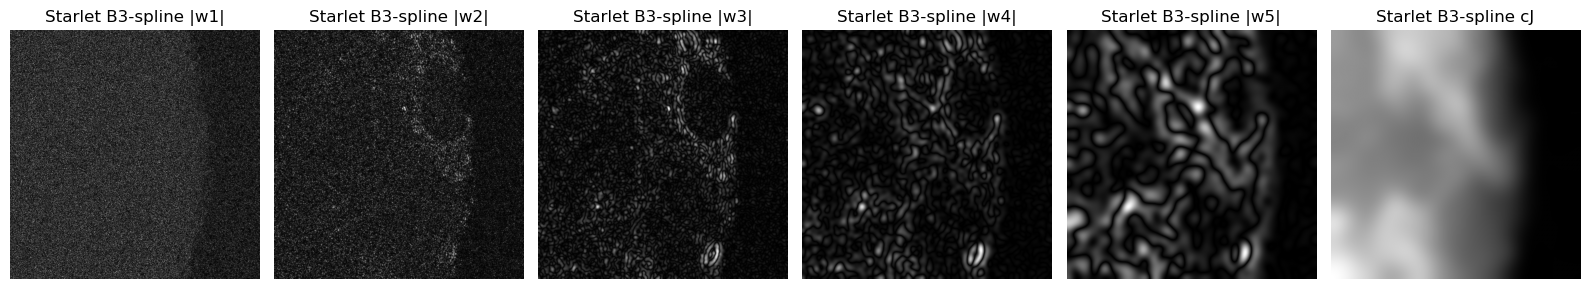

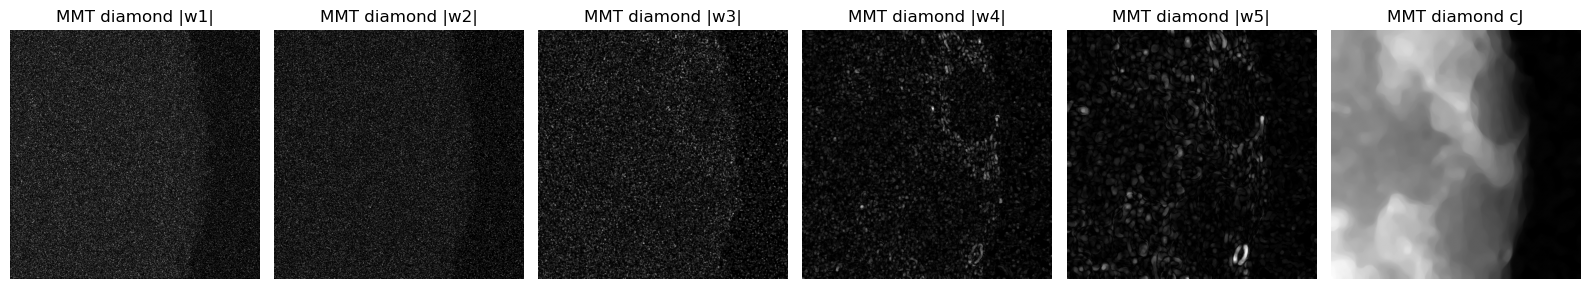

In [12]:
def show_decomposition(details, cJ, title_prefix="", figsize=(16, 4)):
    imgs = []
    titles = []

    for j, w in enumerate(details, start=1):
        w_show = np.abs(w)
        if w_show.max() > 0:
            w_show = w_show / w_show.max()
        imgs.append(w_show)
        titles.append(f"{title_prefix} |w{j}|")

    c_show = cJ.copy()
    c_show = (c_show - c_show.min()) / (c_show.max() - c_show.min() + 1e-12)
    imgs.append(c_show)
    titles.append(f"{title_prefix} cJ")

    show_images(imgs, titles, ncols=6, figsize=figsize)
    plt.show()


example_image = "moon"
example_noise = "gaussian"
example_noisy = noisy_images[(example_image, example_noise)]

details_s, cJ_s, _ = starlet_transform_2d(example_noisy, n_scales=N_SCALES, kernel="b3spline")
details_m, cJ_m, _ = mmt_transform_2d(example_noisy, n_scales=N_SCALES, kernel_type="diamond")

show_decomposition(details_s, cJ_s, title_prefix="Starlet B3-spline")
show_decomposition(details_m, cJ_m, title_prefix="MMT diamond")

## 11. Discusión preliminar

Puntos para redactar en el informe:

1. **Imagen Lunar**: al contener bordes marcados y detalles de alta frecuencia, los métodos pueden eliminar ruido pero también suavizar detalles finos. La umbralización hard suele preservar más contraste, pero puede dejar artefactos residuales.

2. **Imagen de Cielo Profundo**: al contener estructuras difusas y bajo contraste, el denoising es más delicado. La umbralización soft puede producir resultados visualmente más suaves, aunque puede atenuar estructuras débiles.

3. **Starlet**: al ser una transformada lineal y redundante, tiende a representar bien estructuras astronómicas multiescala. El filtro B3-spline suele producir transiciones más suaves que un filtro más compacto.

4. **MMT**: al ser no lineal, puede ser robusta frente a ruido impulsivo y estructuras locales, pero su comportamiento depende fuertemente del kernel de vecindad.

5. **Comparación perceptual**: RMSE mide error punto a punto, mientras que SSIM y HaarPSI capturan mejor similitud estructural/perceptual. Por ello, el mejor método por RMSE no siempre coincide con la mejor apariencia visual.

6. **Bono MMT**: el promedio de descomposiciones con kernel cuadrado y diamante puede reducir sesgos geométricos de cada vecindad individual.

## 12. Cierre de Parte 1

Este notebook deja implementado el pipeline completo de la Parte 1.

Para la versión final se recomienda:

- ajustar los parámetros de ruido para que coincidan exactamente con la Tarea 2;
- seleccionar visualizaciones representativas;
- reportar tabla completa y tabla resumida;
- agregar una discusión separada para imagen lunar y cielo profundo.